# Empirical Finance - 20999

# Lab 2: Log Random Walk

The building blocks of the Gaussian Log Random Walk model are the innovation
(or shock) terms $\varepsilon_t$, which represent the one-period log returns
and are assumed to be i.i.d. normal random variables.

The first step of today's lab, therefore, is to understand how to sample from the normal distribution.

Sampling from a generic distribution (including the normal) relies on the
ability to sample random probabilities, that is, random numbers between $0$
and $1$.

To this end, we rely on one of the many random number generators available in
standard Python packages, which return random numbers in $[0,1]$
(i.e., random draws from a $\text{Uniform}(0,1)$ distribution). These include:

*   the `random()` function from the `random` package;
*   the `np.random.rand()` function from `NumPy.random`;
*   the `uniform.rvs()` from `SciPy.stats`.

In [1]:
import random

x = random.random()

x

0.23660180568017863

In [2]:
import numpy as np

x = np.random.rand()

x

0.0847551692198455

In [3]:
from scipy.stats import uniform

x = uniform.rvs()

x

np.float64(0.7756464426125389)

For the sake of comparability, it is often convenient to fix the seed from which all these "random" numbers are generated. Indeed, the output of these functions is not truly random, but rather pseudo-random: deterministic sequences of numbers based on an initial value (the seed). This seed is itself typically chosen at random when the function is called, often depending on the infinitesimal fraction of a second at which the code is executed. Pseudo-random number generators are designed so that their output passes a wide range of statistical tests for randomness.

In [4]:
np.random.seed(1)

x = np.random.rand()

x

0.417022004702574

Of course, we can generate $n$ random numbers between zero and one simply by specifying the desired dimension of the output.

In [5]:
NSim = 10000

X = np.random.rand(NSim)

In [6]:
X.shape

(10000,)

This allows us to perform some simple checks to verify that the numbers we obtain are indeed uniformly distributed between zero and one. We avoid, for the moment, the more formal comparison between the empirical cumulative distribution function (or probability density function) and the corresponding theoretical ones, which is the standard way to assess whether a sample comes from a given distribution. Such formal procedures will be introduced in Lab 4.

In [7]:
X <= 0.5

array([False,  True,  True, ...,  True, False, False])

In [8]:
sum( X <= 0.5)

np.int64(4989)

In [9]:
sum( X <= 0.5)/NSim

np.float64(0.4989)

In [10]:
Y = np.random.rand(NSim)

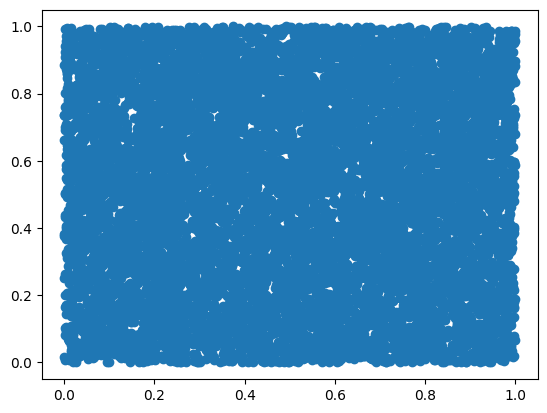

In [11]:
import matplotlib.pyplot as plt

plt.scatter(X,Y);

In [12]:
sum(X + Y <= 1)/NSim

np.float64(0.4975)

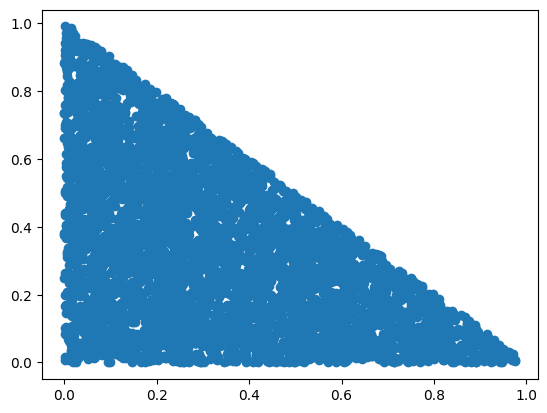

In [13]:
plt.scatter(X[X + Y <= 1],Y[X + Y <= 1]);

In [14]:
sum(X**2 + Y**2 <= 1)/NSim

np.float64(0.7836)

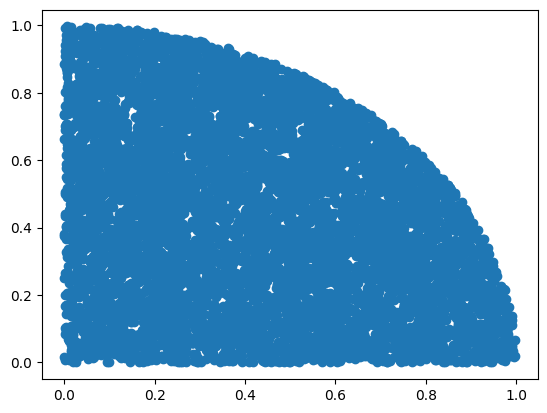

In [15]:
plt.scatter(X[X**2 + Y**2 <= 1],Y[X**2 + Y**2 <= 1]);

In [16]:
np.pi/4

0.7853981633974483

We now turn to the simulation of normally distributed random variables.

Let $\Phi(\cdot)$ denote the cumulative distribution function of the standard normal random variable:
$$
\begin{array}{cccc}
\Phi(x): & \mathbb{R} & \longrightarrow & [0,1] \\
         & x          & \longmapsto     & \Pr\!\left[\,\mathcal{N}(0,1) \leq x \,\right].
\end{array}
$$
Its inverse is given by
$$
\begin{array}{cccc}
\Phi^{-1}(u): & [0,1] & \longrightarrow & \mathbb{R} \\
              & u     & \longmapsto     & x \text{ such that } \Pr\!\left[\,\mathcal{N}(0,1) \leq x \,\right] = u.
\end{array}
$$

If $U \sim \text{Uniform}(0,1)$, then
$$
\Phi^{-1}(U) \sim \mathcal{N}(0,1).
$$
In other words, to generate a realization of a standard normal random variable, one may simply evaluate the inverse of its cumulative distribution function at a uniformly distributed random number in $(0,1)$.

In practice, this can be implemented using the function `norm.ppf()` from the `scipy.stats` package.

In [17]:
from scipy.stats import norm

U = np.random.rand(NSim)

X = norm.ppf(U)

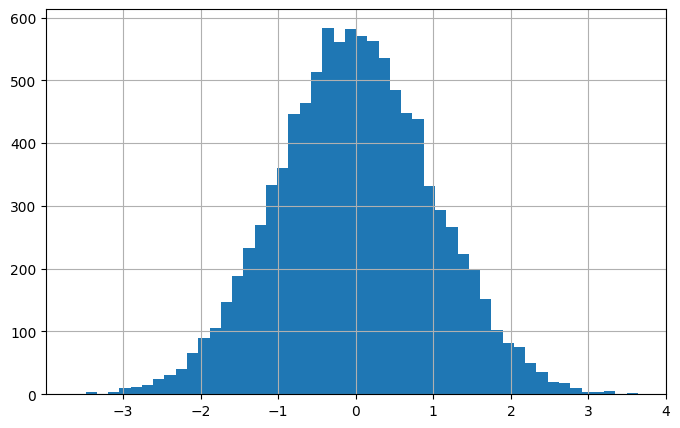

In [18]:
plt.figure(figsize=(8,5))
plt.hist(X, 50)
plt.grid(True)
plt.show()

The same function can also be used to compute quantiles of the standard normal distribution, since
$$
z_\alpha = \Phi^{-1}(\alpha).
$$

In [19]:
norm.ppf(0.025)

np.float64(-1.9599639845400545)

In [20]:
norm.ppf(0.05)

np.float64(-1.6448536269514729)

In [21]:
norm.ppf(0.25)

np.float64(-0.6744897501960817)

Note that `norm` in `scipy.stats` represents an instance of a random variable object, which provides access to its main characteristics and methods. For example, it includes the cumulative distribution function $\Phi(\cdot)$ recalled above, available as `norm.cdf()`, and the probability density function
$$
\begin{array}{cccc}
\phi(x): & \mathbb{R} & \longrightarrow & \mathbb{R}^+ \\
         & x          & \longmapsto     & \displaystyle\frac{1}{\sqrt{2\pi}} \exp \left( -\frac{x^2}{2}\right)
\end{array}
$$
available as `norm.pdf()`.


In [22]:
norm.cdf(0)

np.float64(0.5)

In [23]:
x0 = 0

norm.pdf(x0)

np.float64(0.3989422804014327)

In [24]:
1/np.sqrt(2*np.pi)*np.exp(-x0**2/2)

np.float64(0.3989422804014327)

Of course, `NumPy` provides its own built-in functions to generate one-dimensional or multi-dimensional arrays filled with normally distributed random numbers.

In [25]:
X = np.random.normal(loc = 0, scale = 1, size = NSim)

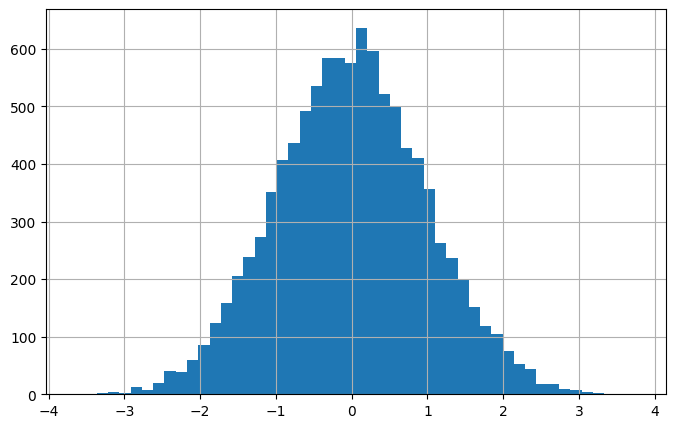

In [26]:
plt.figure(figsize=(8,5))
plt.hist(X, 50)
plt.grid(True)
plt.show()

Non-standard normal random variables can be generated either by adjusting the location and scale parameters in `np.random.normal()`, or by exploiting the basic properties of the normal distribution.

In [27]:
mu = 1
sigma = 2

x = np.random.normal(loc = mu, scale = sigma)

In [28]:
x = mu +sigma*np.random.normal(0,1)

We now consider the (Gaussian) Log Random Walk model, with the objective of simulating a few trajectories of the price process of a given security, initialized at $P_0 = 100$.

The simulation is performed at a daily frequency (assuming 250 trading days per year, so that $\Delta = \tfrac{1}{250}$ years) over a time horizon of $T = 2$ years.

The annual parameters of the model are specified as $\mu = 0.1$ and $\sigma^2 = 0.09$ (equivalently, $\sigma = 0.3$).

As a preliminary step, we determine the total number of time steps (or monitoring dates) `m` at which the process will be simulated, along with the corresponding daily parameters, $\mu_D$ and $\sigma_D$ relying on the annualization formulae (see Proposition 2.3 of the Lecture Notes).

In [29]:
T = 2
m = 250*T

mu = 0.1
sigma = np.sqrt(0.09)

muD = mu/250
sigmaD = sigma/np.sqrt(250)

P0 = 100

We can now simulate the evolution of the price process over time, at a daily frequency, trajectory by trajectory, according to
$$
P_t = P_{t-1} \, e^{\varepsilon_t},
\qquad \varepsilon_t \sim \mathcal{N}(\mu_D, \sigma_D^2),
$$
with the initial condition $P_0 = 100$.

We start with the simulation of just one trajectory.

In [30]:
P = np.zeros(m+1)

P[0] = P0

for j in range(m):
  P[j+1] = P[j]*np.exp( np.random.normal(loc = muD, scale = sigmaD) )

Alternatively, we may use the annual parameters $\mu$ and $\sigma$, together with the time-step length
$\Delta = \tfrac{T}{m} = \tfrac{1}{250}$ and standard normal shocks
$\varepsilon_t \sim \mathcal{N}(0,1)$. In this case, we have
$$
\mu \Delta + \sigma \sqrt{\Delta}\,\mathcal{N}(0,1)
\sim \mathcal{N}(\mu \Delta, \sigma^2 \Delta) = \mathcal{N}(\mu_D, \sigma_D^2),
$$
where $\mu_D = \tfrac{\mu}{250}$ and $\sigma_D^2 = \tfrac{\sigma^2}{250}$.

In [31]:
Delta = T/m

for j in range(m):
  P[j+1] = P[j]*np.exp( Delta*mu + sigma*np.sqrt(Delta)*np.random.normal(0,1) )

We can now plot this trajectory and replace the default
$x$-axis, which currently shows the monitoring date index
$i \in \{0, 1, 2, \ldots, m\}$, with the corresponding time values
$t \in \{ i \Delta \}_{i=0}^{m} = \left\{ \tfrac{i}{250} \right\}_{i=0}^{m}$.

In [32]:
ts = np.linspace(0,T,m+1)

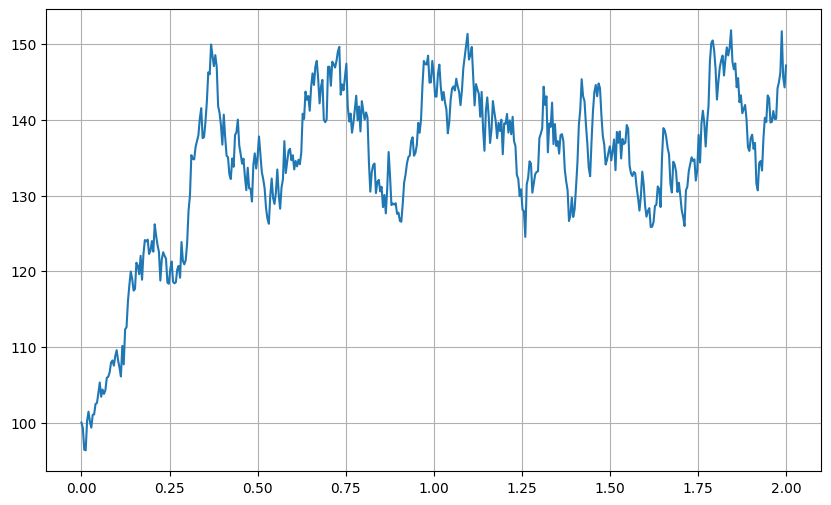

In [33]:
plt.figure(figsize=(10,6))

plt.plot(ts, P)

plt.grid(True)
plt.show()

We now aim to simulate `NSim = 10000` trajectories.

As is common in such simulation frameworks, we can store the different
trajectories of the process in an `NSim` $ \times (m+1)$ matrix, where each
row corresponds to a trajectory and each column to a point in time.


In [34]:
NSim = 10000

P = np.zeros(shape=(NSim,m+1))

P[:,0] = P0

for i in range(NSim):
  for j in range(m):
    P[i,j+1] = P[i,j]*np.exp( np.random.normal(loc = muD, scale = sigmaD) )

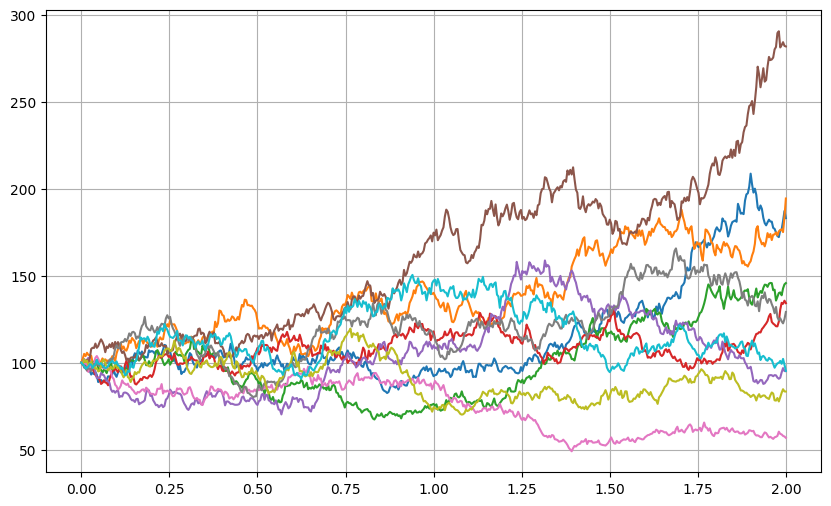

In [35]:
plt.figure(figsize=(10,6))

for i in range(10):
  plt.plot(ts, P[i,:])

plt.grid(True)
plt.show()

From these trajectories, we can also extract the one-period (i.e., daily) log returns.

In [36]:
r = np.log(P[:,1:]/P[:,:-1])

In [37]:
import pandas as pd

r_df = pd.DataFrame(r)
r_df

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,0.018021,-0.045759,0.005414,-0.024169,0.001533,-0.003599,-0.022180,0.011480,-0.009037,0.013245,...,-0.019960,-0.003248,-0.011602,-0.011816,-0.003669,0.022423,0.002208,0.027513,0.031197,-0.021839
1,0.022218,0.026975,-0.012343,0.018573,-0.012096,-0.001299,-0.003186,-0.037023,0.002164,0.006193,...,0.017912,0.000783,0.006859,-0.010066,0.013475,0.004091,0.002414,-0.008960,0.048286,0.056285
2,-0.006621,0.010297,-0.036524,0.015416,-0.004772,0.014842,-0.011948,0.013831,0.011753,-0.009048,...,-0.028351,0.002138,-0.045130,0.015600,0.015883,0.002495,-0.011840,0.028091,0.016161,0.005094
3,0.002665,-0.016618,-0.017763,-0.011323,-0.008807,0.030350,-0.017985,0.002522,-0.017382,-0.019565,...,-0.008070,-0.005081,-0.007435,-0.000264,0.021945,0.054367,0.029543,-0.004197,0.013227,-0.010367
4,0.003500,0.016704,-0.010314,-0.002234,0.020382,-0.018380,-0.010643,-0.020009,-0.003380,-0.031898,...,-0.006057,0.006881,-0.001589,-0.013707,-0.007603,0.006471,0.032864,0.026077,-0.017664,-0.000373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.002930,-0.015612,0.006710,-0.003399,-0.021032,0.036849,-0.008264,-0.020505,0.002371,0.018569,...,0.022442,0.017895,0.046938,-0.012392,0.003008,-0.002707,0.031587,0.032930,0.024766,0.001461
9996,0.002461,-0.017310,0.002443,0.007359,0.015229,0.007951,0.023679,0.060204,-0.029242,0.035261,...,-0.017949,-0.019304,0.032736,0.040872,0.009363,-0.022506,0.014640,-0.028878,-0.000418,-0.006112
9997,-0.017838,0.000060,0.042720,0.017324,-0.020543,0.021995,-0.006845,0.001529,-0.001778,-0.020313,...,-0.006602,0.006581,0.018997,0.006955,0.000971,0.034495,0.049740,-0.009298,0.018019,-0.007955
9998,-0.002982,-0.001636,0.002289,0.026896,0.004731,0.031117,0.013398,0.024363,-0.005604,0.010122,...,0.019852,0.009102,-0.005786,-0.019261,-0.023877,0.017067,-0.037859,0.032784,-0.011840,-0.033365


Focusing on a specific trajectory (for instance, the first one), we can analyze the sample distribution of the daily log returns.
Since these returns are random realizations from the underlying random shock, they exhibit variability across time even within a single trajectory.


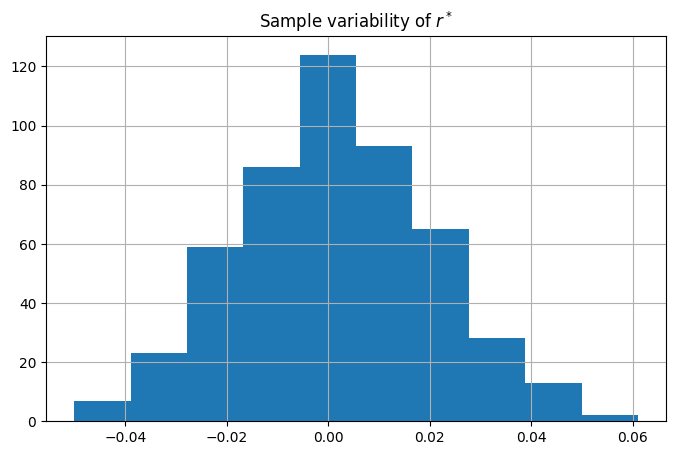

In [38]:
plt.figure(figsize=(8,5))
plt.title(r"Sample variability of $r^*$")
plt.hist(r[0,:])
plt.grid(True)
plt.show()

Along the first trajectory, the sample mean of the log returns can be easily computed using the `.mean()` function.
In this way, we obtain the daily sample mean of the log returns, which can then be annualized in the standard manner.

In [39]:
r[0,:].mean()

np.float64(0.0012096617778991233)

In [40]:
r[0,:].mean()*250

np.float64(0.3024154444747808)

Finally, we can exploit the simulated variability across different realizations
of the market to study the sampling variability of the parameter estimators in
the Log Random Walk model.

For instance, we may compute the estimator of $\mu$ for each trajectory and
examine how the resulting values of $\hat{\mu}$ differ from the true value of
$\mu$, which in this setting is known.

Recall that $\hat{\mu}$ can be estimated as the sample mean (over time) of the
daily log returns along any given trajectory. For the sake of readability, it
can then be annualized again using the standard annualization formulas.

In [41]:
mu_hats = np.mean(r, axis = 1)

In [42]:
mu_hats_df = pd.DataFrame(mu_hats)
mu_hats_df*250

,0
0,0.302415
1,0.332230
2,0.188316
3,0.147104
4,-0.024864
...,...
9995,0.152670
9996,0.245828
9997,-0.079406
9998,-0.205780


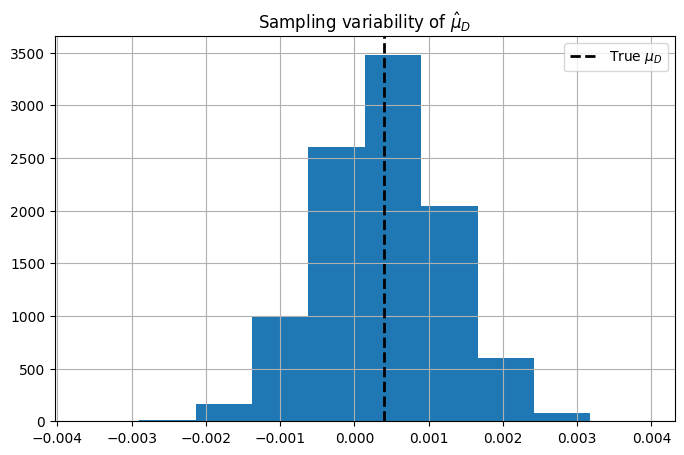

In [43]:
plt.figure(figsize=(8,5))
plt.title(r"Sampling variability of $\hat{\mu}_D$")
plt.hist(mu_hats)
plt.axvline(muD, color="black", linestyle="--", linewidth=2, label=r"True $\mu_D$")
plt.legend()
plt.grid(True)
plt.show()

We can equivalently plot the same graph on an annualized basis and add the empirical 2.5\% and 97.5\% quantiles of the distribution of $\hat{\mu}$, thereby obtaining the empirical (estimated) 95\% confidence interval for $\mu$.

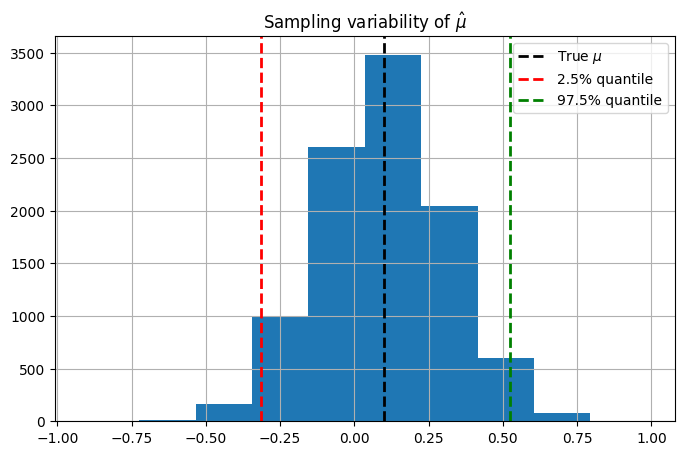

In [44]:
q025_mu = np.quantile(mu_hats*250, 0.025)
q975_mu = np.quantile(mu_hats*250, 0.975)

plt.figure(figsize=(8,5))
plt.title(r"Sampling variability of $\hat{\mu}$")
plt.hist(mu_hats*250)
plt.axvline(mu, color="black", linestyle="--", linewidth=2, label=r"True $\mu$")
plt.axvline(q025_mu, color="red", linestyle="--", linewidth=2, label=r"2.5% quantile")
plt.axvline(q975_mu, color="green", linestyle="--", linewidth=2, label=r"97.5% quantile")
plt.legend()
plt.grid(True)
plt.show()

As expected, the 95\% confidence interval for $\mu$ is quite wide, even though it is based on an average of 500 daily log returns.
Thus, having such "high-frequency" data points does not provide much help in improving the precision of the estimator.

In contrast, the estimators of $\sigma^2$ (and even more so of $\sigma$) are considerably more precise.

In [45]:
sigma2_hats = np.var(r, axis = 1)

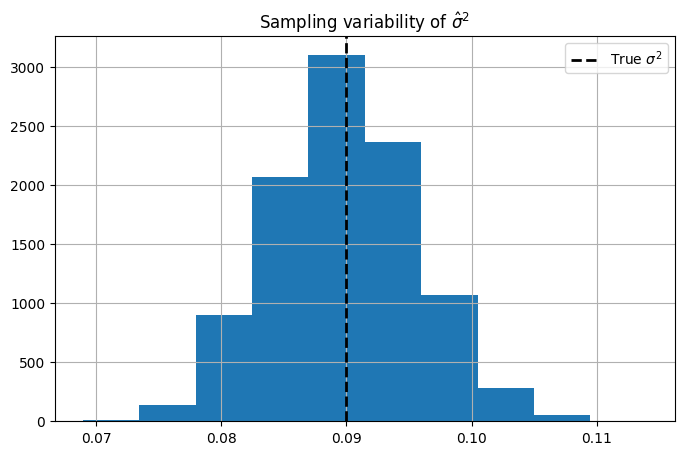

In [46]:
plt.figure(figsize=(8,5))
plt.title(r"Sampling variability of $\hat{\sigma}^2$")
plt.hist(sigma2_hats*250)
plt.axvline(sigma**2, color="black", linestyle="--", linewidth=2, label=r"True $\sigma^2$")
plt.legend()
plt.grid(True)
plt.show()

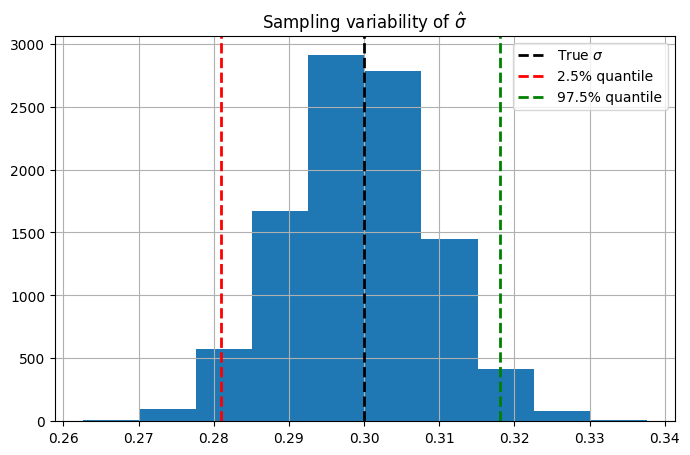

In [47]:
q025_sigma = np.quantile(np.sqrt(sigma2_hats*250), 0.025)
q975_sigma = np.quantile(np.sqrt(sigma2_hats*250), 0.975)

plt.figure(figsize=(8,5))
plt.title(r"Sampling variability of $\hat{\sigma}$")
plt.hist(np.sqrt(sigma2_hats*250))
plt.axvline(sigma, color="black", linestyle="--", linewidth=2, label=r"True $\sigma$")
plt.axvline(q025_sigma, color="red", linestyle="--", linewidth=2, label=r"2.5% quantile")
plt.axvline(q975_sigma, color="green", linestyle="--", linewidth=2, label=r"97.5% quantile")
plt.legend()
plt.grid(True)
plt.show()

### BONUS 1: The simulation of the symmetric random walk

We now analyze and simulate the simplest instance of a random walk:
the symmetric random walk, defined as follows.

Let $\{X_t\}_{t \in \mathbb{N}}$ be a stochastic process
(i.e., a sequence of random variables indexed by time) starting at $X_0 = 0$
and defined recursively by
$$
X_t = X_{t-1} + \varepsilon_t, \quad t \in \mathbb{N}_0,
$$
where
$$
\varepsilon_t =
\begin{cases}
+1 & \text{with probability } 0.5, \\[6pt]
-1 & \text{with probability } 0.5,
\end{cases}
\qquad t \in \mathbb{N}_0.
$$

To simulate a few trajectories of this random walk, it is convenient to introduce a simple function that generates random realizations of the innovation (or shock) term $\varepsilon_t$ with the desired distribution.

In [48]:
def epsilonShock():
  u = np.random.rand()
  if u<=0.5:
    return +1
  else:
    return -1

In [49]:
epsilonShock()

1

In [50]:
epsilons = np.zeros(NSim)

for i in range(int(NSim)):
  epsilons[i] = epsilonShock()

In [51]:
sum( epsilons == 1 )

np.int64(4993)

In [52]:
sum( epsilons == -1 )

np.int64(5007)

Of course, `NumPy` also provides a built-in function for this purpose: `np.random.choice([-1, 1])`.

In [53]:
epsilons = np.random.choice([-1,1],NSim)

In [54]:
sum( epsilons == 1 )

np.int64(4965)

In [55]:
sum( epsilons == -1 )

np.int64(5035)

We can now simulate one trajector of a random walk featuring $m=100$ steps.

In [56]:
m = 100

X = np.zeros(m+1)
X[0] = 0

for i in range(m):
  X[i+1] = X[i] + np.random.choice([-1,1])

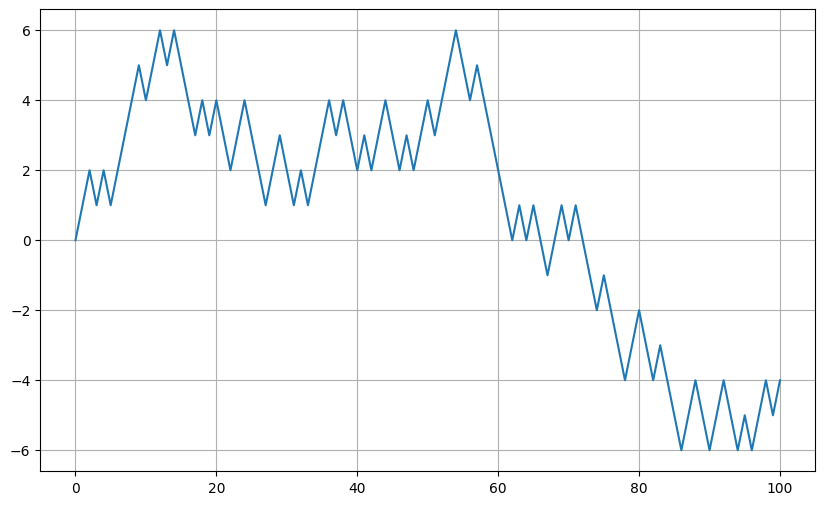

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(X)
plt.grid(True)
plt.show()

As in the previous lab, we can avoid the slow loop here as well by properly vectorizing the construction of the path (see also BONUS 2 below).

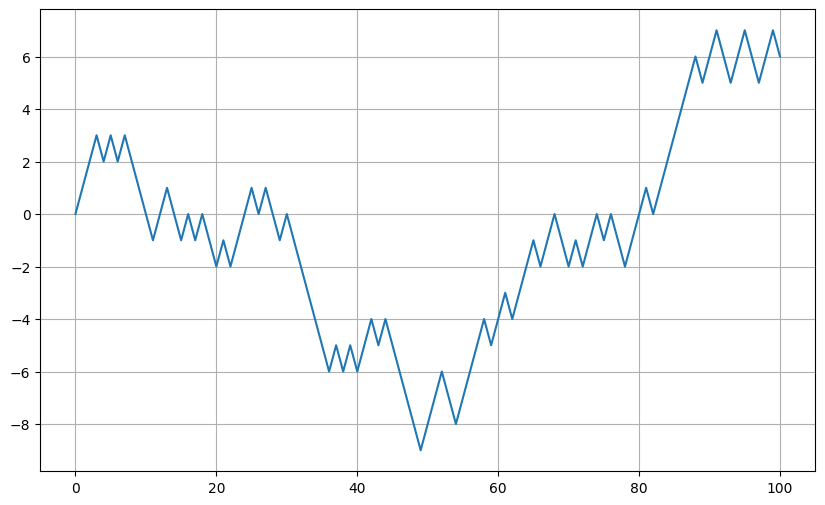

In [58]:
epsilons = np.random.choice([-1, 1], m)

X = np.zeros(m+1)
X[1:] = np.cumsum(epsilons)

plt.figure(figsize=(10,6))
plt.plot(X)
plt.grid(True)
plt.show()

Of course, we can also simulate $n$ trajectories with $m$ steps

In [59]:
n = 10000

X = np.zeros(shape=(n,m+1))
X[:,0] = 0

for i in range(n):
  for j in range(m):
    X[i,j+1] = X[i,j] + np.random.choice([-1,1])

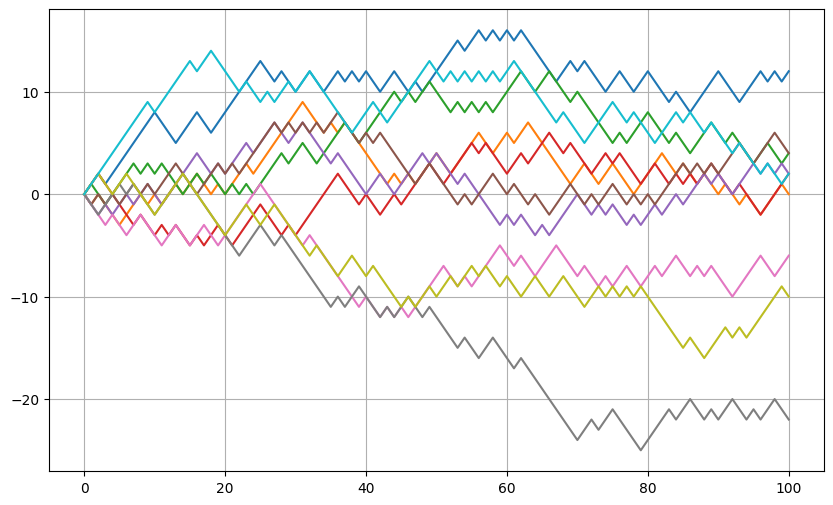

In [60]:
plt.figure(figsize=(10,6))

for i in range(10):
  plt.plot(X[i,:])

plt.grid(True)
plt.show()

Finally, we analyze the distribution of the terminal values (after $m$ steps)
of these symmetric random walks.

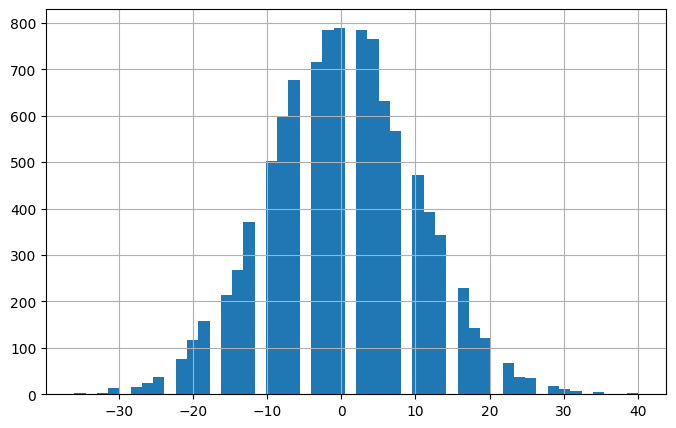

In [61]:
plt.figure(figsize=(8,5))
plt.hist(X[:,-1], 50)
plt.grid(True)
plt.show()

We observe that the distribution appears to be quite close to that of a normal
random variable: but this is not surprising. In fact, it can be shown that the
distribution of the terminal values of a symmetric random walk is binomial, and
as the number of steps increases, it converges to the normal distribution...

### BONUS 2: Further details on the computational efficency of loops

From a computational efficiency perspective, double nested loops are clearly even less efficient than a single loop.

In principle, we can vectorize the kind of simulations introduced above along both dimensions.

Below we compare the computational times (measured using the `time()` function from the `time` package) for the simulation of a simple random walk using three approaches:  
1.   a double loop;
2.   a single loop over the simulations, with each trajectory generated in a vectorized way;  
3.   no loop at all, with all trajectories generated simultaneously in a multidimensional vectorized form.  

In [62]:
import time

n = 20000
m = 100

X = np.zeros(shape=(n,m+1))
X[:,0] = 0

In [63]:
start = time.time()

X = np.zeros(shape=(n,m+1))
X[:,0] = 0

for i in range(int(n)):
  for j in range(int(m)):
    X[i,j+1] = X[i,j] + np.random.choice([-1,1])

end = time.time()

print(f"Elapsed time of double for loop: {end - start:.4f} seconds")

Elapsed time of double for loop: 28.0617 seconds


In [64]:
start = time.time()

X = np.zeros(shape=(n,m+1))
X[:,0] = 0

for i in range(int(n)):
  epsilons = np.random.choice([-1, 1], m)
  X[i,1:] = np.cumsum(epsilons)

end = time.time()

print(f"Elapsed time of one loop + one vectorization: {end - start:.4f} seconds")

Elapsed time of one loop + one vectorization: 0.4996 seconds


In [65]:
start = time.time()

X = np.zeros((n, m+1))
X[:,0] = 0

epsilons = np.random.choice([-1, 1], size=(n, m))
X[:, 1:] = np.cumsum(epsilons, axis=1)

end = time.time()

print(f"Elapsed time of two vectorizations: {end - start:.4f} seconds")

Elapsed time of two vectorizations: 0.0383 seconds
